In [10]:
#regular packages
from matplotlib import pyplot as plt
import numpy as np
import networkx as nx
import pandas as pd
import torch
#Geometric
from torch_geometric.utils import degree, contains_isolated_nodes, to_networkx
import torch_geometric.transforms as T
from torch_geometric.utils import degree
from torch_geometric.utils import to_networkx

# Neighborloader to handle large datasets
from torch_geometric.loader import NeighborLoader


#Datasets
#Homogeneous
from torch_geometric.datasets import Planetoid
from torch_geometric.datasets import PPI
from torch_geometric.datasets import Reddit

#Heterogeneous
from torch_geometric.datasets import IMDB
from torch_geometric.datasets import DBLP
from torch_geometric.datasets import AMiner

#Knowledge Graphs
from torch_geometric.datasets import FB15k_237
from torch_geometric.datasets import WordNet18RR

#Heterophilous
from torch_geometric.datasets import WebKB
from torch_geometric.datasets import WikipediaNetwork
from torch_geometric.datasets import Actor


#networkx
import networkx as nx



# Homogeneous

## Cora

In [3]:
dataset = Planetoid(root='../data/', name='Cora', transform=T.NormalizeFeatures())
data = dataset[0]  # The Cora dataset consists of a single large graph
data.keys()
data.num_node_features

Processing...
Done!


1433

In [27]:
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Number of nodes: 2708
Number of edges: 10556
Average node degree: 3.90
Number of training nodes: 140
Has isolated nodes: False
Has self-loops: False
Is undirected: True


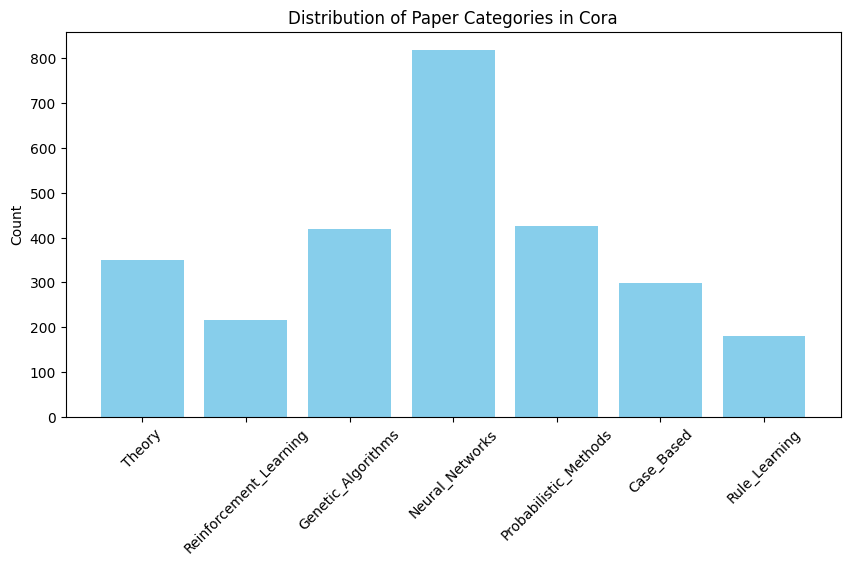

In [28]:
labels = data.y.numpy()
unique, counts = np.unique(labels, return_counts=True)
label_names = ['Theory', 'Reinforcement_Learning', 'Genetic_Algorithms', 
               'Neural_Networks', 'Probabilistic_Methods', 'Case_Based', 'Rule_Learning']

plt.figure(figsize=(10, 5))
plt.bar(label_names, counts, color='skyblue')
plt.xticks(rotation=45)
plt.title('Distribution of Paper Categories in Cora')
plt.ylabel('Count')
plt.show()

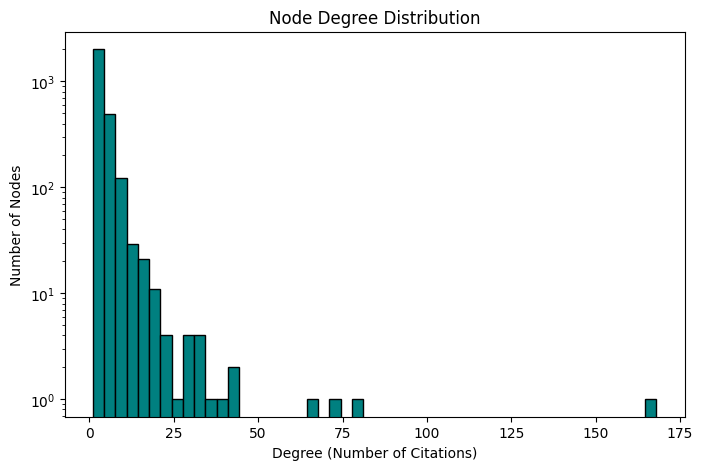

In [15]:
node_degrees = degree(data.edge_index[0]).numpy()

plt.figure(figsize=(8, 5))
plt.hist(node_degrees, bins=50, color='teal', edgecolor='black')
plt.title('Node Degree Distribution')
plt.xlabel('Degree (Number of Citations)')
plt.ylabel('Number of Nodes')
plt.yscale('log') # Log scale helps visualize long-tail distributions
plt.show()

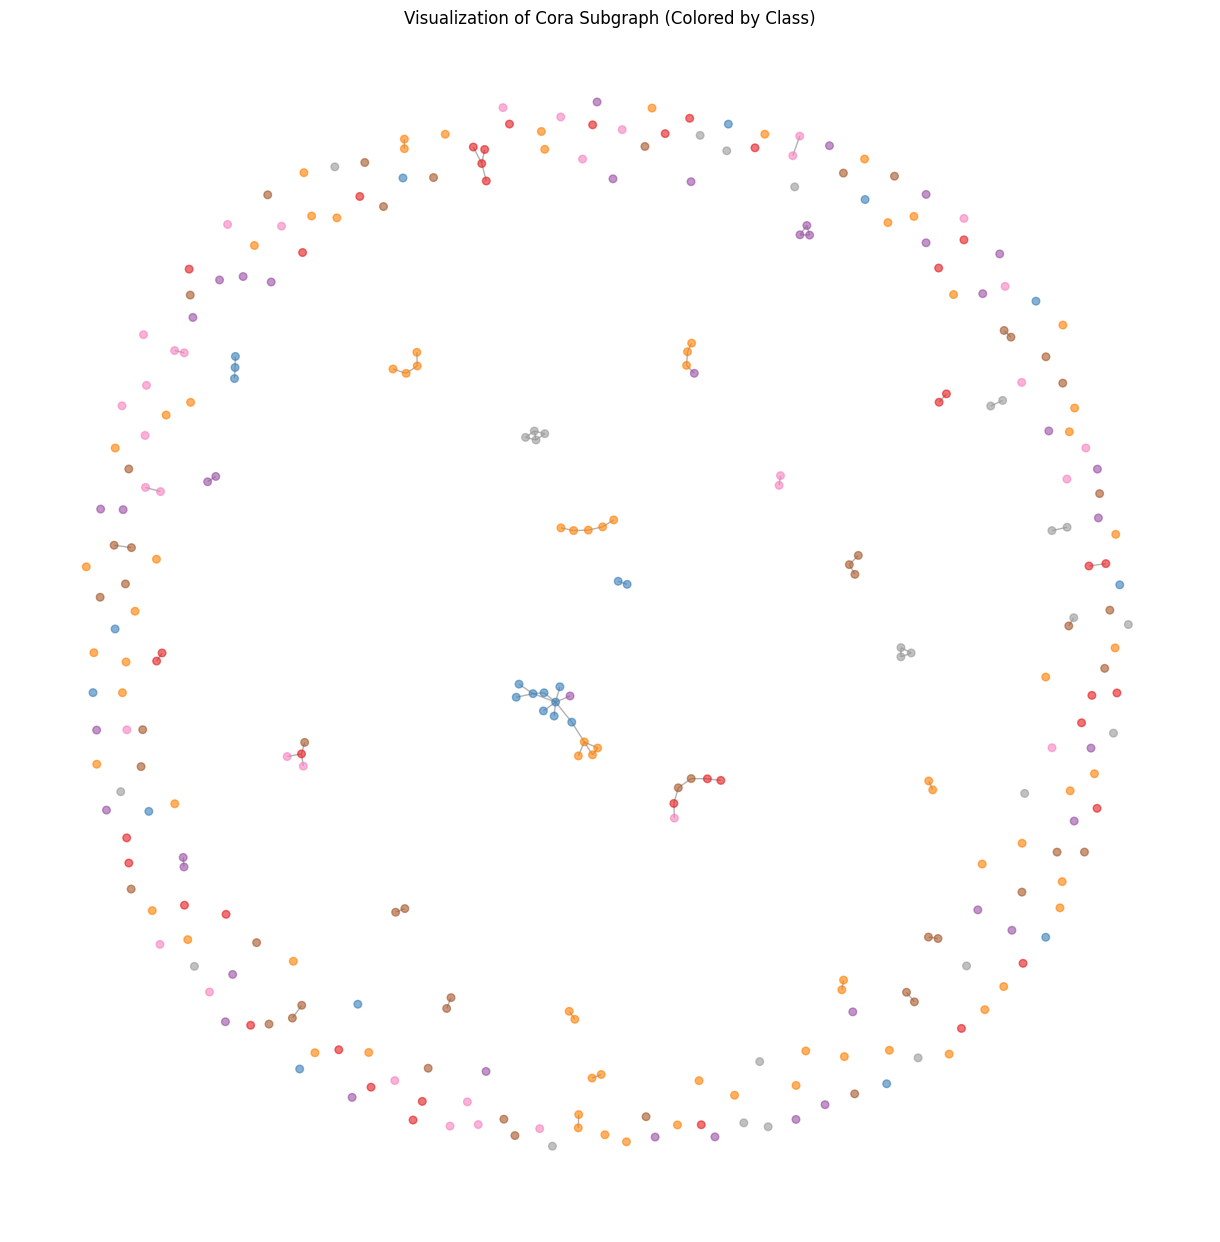

In [17]:

# Convert to NetworkX
G = to_networkx(data, to_undirected=True)

# To visualize clearly, let's take a subset (first 300 nodes)
node_subset = range(300)
subgraph = G.subgraph(node_subset)

# Get labels for the subset
node_color = data.y[list(node_subset)].numpy()

plt.figure(figsize=(12, 12))
nx.draw_spring(subgraph, node_size=30, node_color=node_color, 
               cmap=plt.cm.Set1, with_labels=False, edge_color='gray', alpha=0.6)
plt.title('Visualization of Cora Subgraph (Colored by Class)')
plt.show()

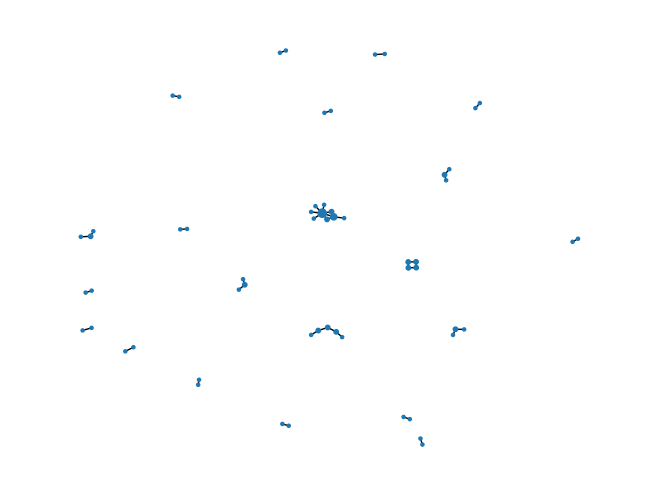

In [25]:

# Convert to NetworkX
G = to_networkx(data, to_undirected=True)
subgraph = G.subgraph(range(250,450))
nx.draw(subgraph, node_size = [i*1000 for i in nx.degree_centrality(subgraph).values()])

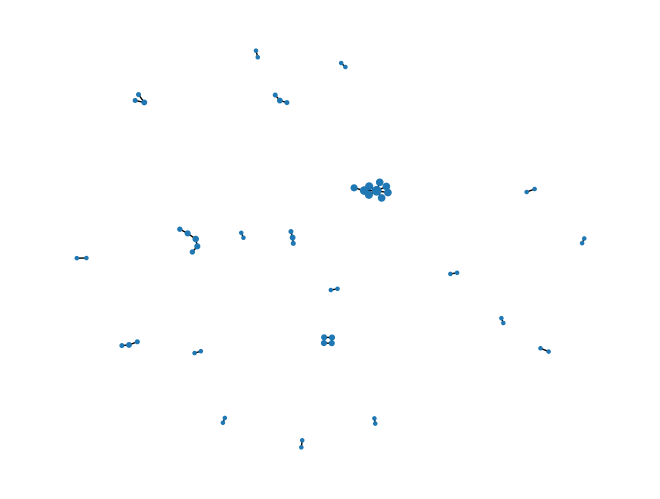

In [26]:
nx.draw(subgraph, node_size = [i*1000 for i in nx.closeness_centrality(subgraph).values()])

In [27]:
nx.number_connected_components(subgraph)

163

## CiteSeer

In [24]:
dataset = Planetoid(root='../data/', name='CiteSeer', transform=T.NormalizeFeatures())
data = dataset[0]  # The CiteSeer dataset consists of a single large graph
data.num_node_features
data.num_edge_features


0

In [22]:
print(f'Number of nodes: {data.num_nodes}')
print(f'Number of edges: {data.num_edges}')
print(f'Average node degree: {data.num_edges / data.num_nodes:.2f}')
print(f'Number of training nodes: {data.train_mask.sum()}')
print(f'Has isolated nodes: {data.has_isolated_nodes()}')
print(f'Has self-loops: {data.has_self_loops()}')
print(f'Is undirected: {data.is_undirected()}')

Number of nodes: 3327
Number of edges: 9104
Average node degree: 2.74
Number of training nodes: 120
Has isolated nodes: True
Has self-loops: False
Is undirected: True


In [35]:
isolated = contains_isolated_nodes(data.edge_index, num_nodes=data.num_nodes)
print(f"Does CiteSeer have isolated nodes? {isolated}")

# Count them
node_degrees = degree(data.edge_index[0], num_nodes=data.num_nodes)
num_isolated = (node_degrees == 0).sum().item()
print(f"Number of isolated nodes: {num_isolated} ({num_isolated/data.num_nodes:.2%})")

Does CiteSeer have isolated nodes? True
Number of isolated nodes: 48 (1.44%)


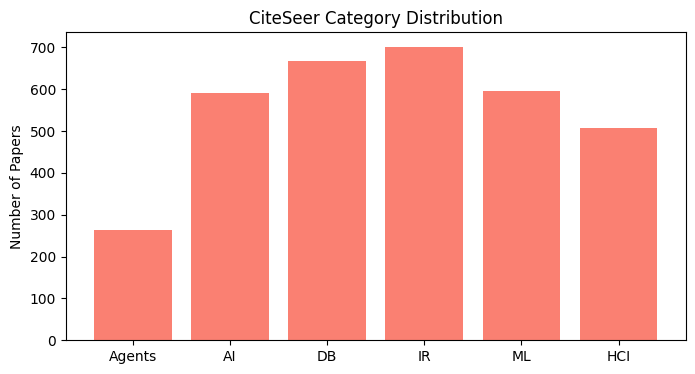

In [36]:
label_names = ['Agents', 'AI', 'DB', 'IR', 'ML', 'HCI']
unique, counts = np.unique(data.y.numpy(), return_counts=True)

plt.figure(figsize=(8, 4))
plt.bar(label_names, counts, color='salmon')
plt.title('CiteSeer Category Distribution')
plt.ylabel('Number of Papers')
plt.show()

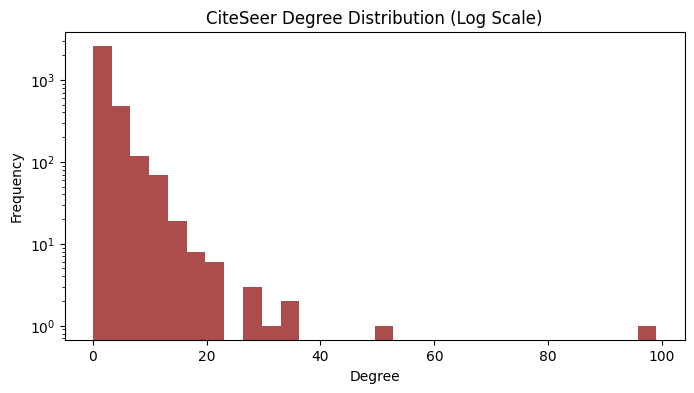

In [37]:
# Degree distribution
plt.figure(figsize=(8, 4))
plt.hist(node_degrees.numpy(), bins=30, color='darkred', alpha=0.7)
plt.title('CiteSeer Degree Distribution (Log Scale)')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.yscale('log')
plt.show()

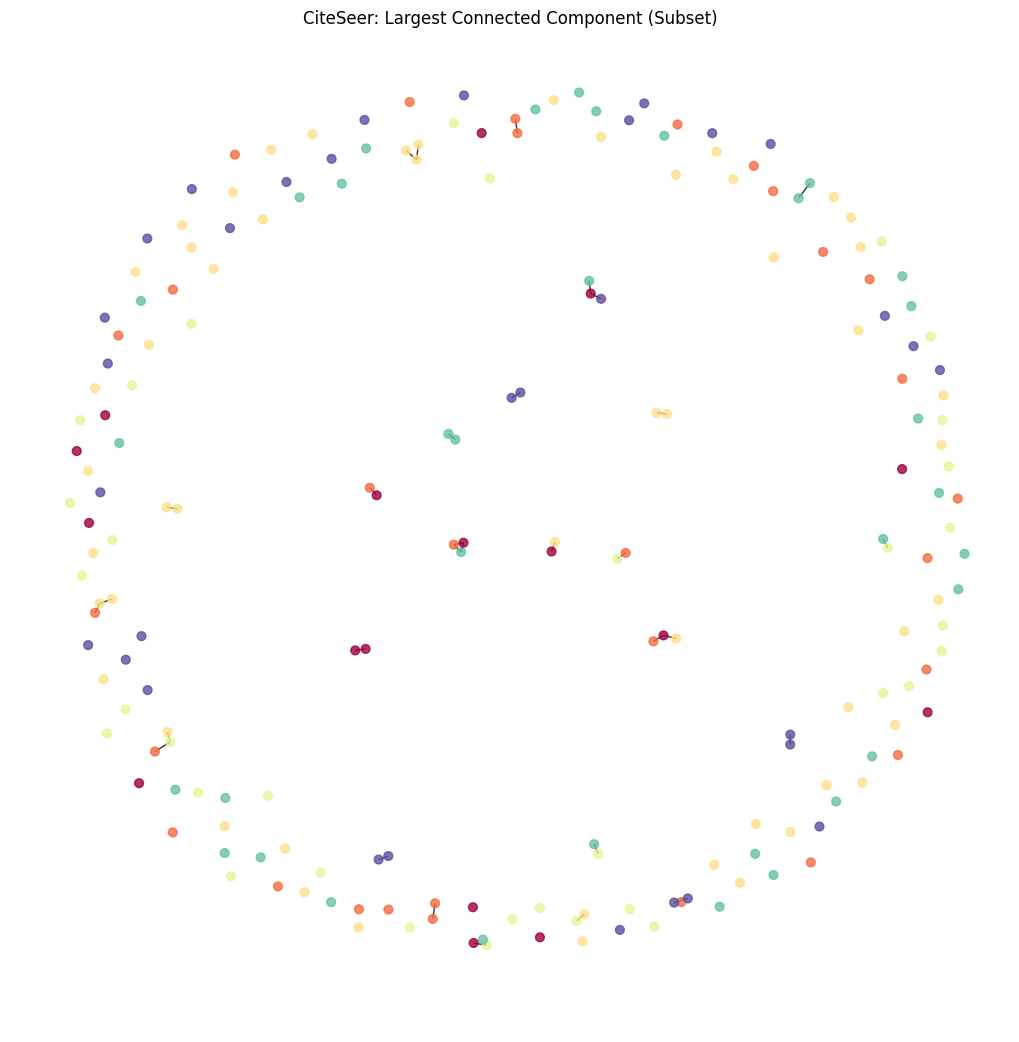

In [38]:
G = to_networkx(data, to_undirected=True)
# Get the largest connected component
largest_cc = max(nx.connected_components(G), key=len)
subgraph = G.subgraph(largest_cc)

# Limit for visualization (first 200 nodes of the largest component)
view_nodes = list(largest_cc)[:200]
small_subgraph = G.subgraph(view_nodes)

plt.figure(figsize=(10, 10))
pos = nx.spring_layout(small_subgraph, seed=42)
nx.draw(small_subgraph, pos, node_size=40, 
        node_color=data.y[view_nodes].numpy(), 
        cmap=plt.cm.Spectral, with_labels=False, alpha=0.8)
plt.title('CiteSeer: Largest Connected Component (Subset)')
plt.show()

## PubMed

In [27]:
dataset = Planetoid(root='../data', name='PubMed', transform=T.NormalizeFeatures())
data = dataset[0]  # The CiteSeer dataset consists of a single large graph
data.num_node_features
data.num_edge_features


0

In [41]:
print(f'Nodes: {data.num_nodes}')
print(f'Edges: {data.num_edges}')
print(f'Classes: {dataset.num_classes}')
print(f'Features per node: {data.num_node_features}')
print(f'Is directed: {data.is_directed()}')

Nodes: 19717
Edges: 88648
Classes: 3
Features per node: 500
Is directed: False


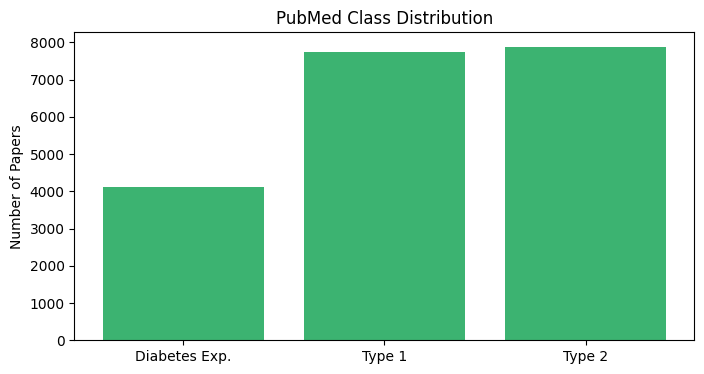

In [42]:
labels = data.y.numpy()
unique, counts = np.unique(labels, return_counts=True)
categories = ['Diabetes Exp.', 'Type 1', 'Type 2']

plt.figure(figsize=(8, 4))
plt.bar(categories, counts, color='mediumseagreen')
plt.title('PubMed Class Distribution')
plt.ylabel('Number of Papers')
plt.show()

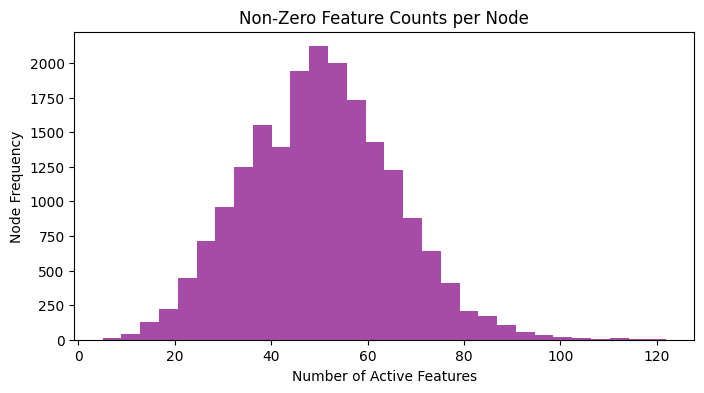

In [43]:
# Calculate how many features are non-zero per node
non_zero_counts = (data.x > 0).sum(dim=1).numpy()

plt.figure(figsize=(8, 4))
plt.hist(non_zero_counts, bins=30, color='purple', alpha=0.7)
plt.title('Non-Zero Feature Counts per Node')
plt.xlabel('Number of Active Features')
plt.ylabel('Node Frequency')
plt.show()

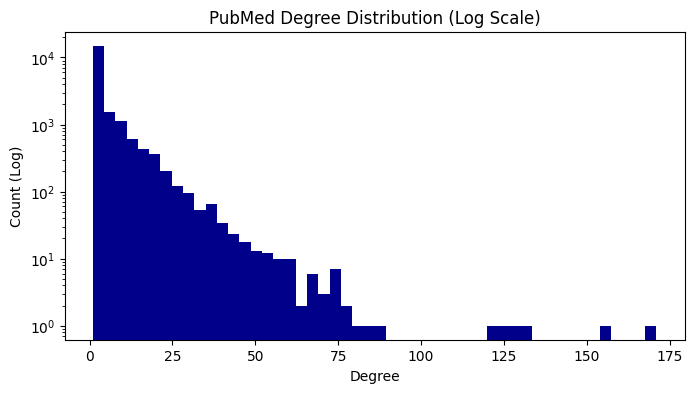

In [44]:
from torch_geometric.utils import degree

node_degrees = degree(data.edge_index[0], num_nodes=data.num_nodes).numpy()

plt.figure(figsize=(8, 4))
plt.hist(node_degrees, bins=50, color='darkblue', log=True)
plt.title('PubMed Degree Distribution (Log Scale)')
plt.xlabel('Degree')
plt.ylabel('Count (Log)')
plt.show()

## Protein Protein Interaction

In [6]:
# Training set: 20 graphs
train_dataset = PPI(root='../data/PPI', split='train')
# Validation: 2 graphs | Test: 2 graphs
test_dataset = PPI(root='../data/PPI', split='test')

# Inspect the first graph in the training set
data = train_dataset[0]

Extracting ../data/PPI/ppi.zip
Processing...
Done!


In [3]:
print(f"Number of labels per node: {train_dataset.num_classes}") # 121
print(f"Example label vector: {data.y[0]}") # Vector of 0s and 1s

# Check label density (how many labels are active on average per node)
label_density = data.y.sum(dim=1).mean().item()
print(f"Average active labels per node: {label_density:.2f}")

Number of labels per node: 121
Example label vector: tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 0., 1.,
        0., 1., 0., 1., 0., 0., 0., 1., 1., 0., 1., 0., 1., 1., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.,
        1., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0., 0.,
        0., 0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 0.])
Average active labels per node: 36.80


In [6]:
graph_stats = []
for i, g in enumerate(train_dataset):
    graph_stats.append({
        'graph_id': i,
        'nodes': g.num_nodes,
        'edges': g.num_edges,
        'avg_degree': g.num_edges / g.num_nodes
    })

df_stats = pd.DataFrame(graph_stats)
print(df_stats.describe())

       graph_id        nodes          edges  avg_degree
count  20.00000    20.000000      20.000000   20.000000
mean    9.50000  2245.300000   61318.400000   25.781055
std     5.91608   766.158641   28601.165538    5.012635
min     0.00000   591.000000    7708.000000   13.042301
25%     4.75000  1806.000000   42288.000000   23.966882
50%     9.50000  2332.500000   62040.000000   26.551260
75%    14.25000  2799.250000   85368.500000   29.885020
max    19.00000  3480.000000  106754.000000   32.064614


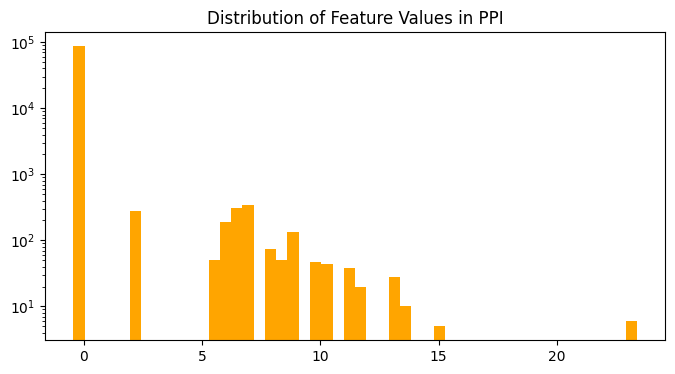

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(data.x.numpy().flatten(), bins=50, color='orange')
plt.title('Distribution of Feature Values in PPI')
plt.yscale('log')
plt.show()

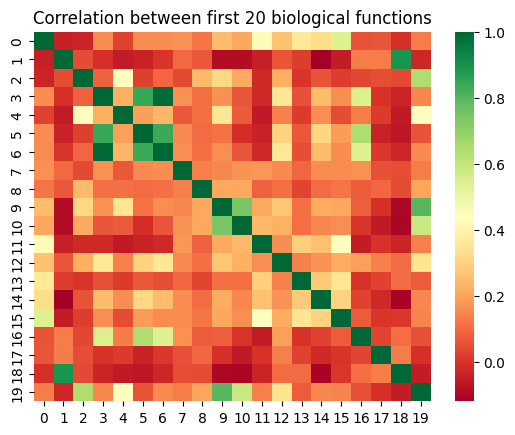

In [8]:
import seaborn as sns

# Correlation between the first 20 labels
label_corr = pd.DataFrame(data.y[:, :20].numpy()).corr()
sns.heatmap(label_corr, cmap='RdYlGn')
plt.title('Correlation between first 20 biological functions')
plt.show()

In [84]:
# 2. Download and load the training, validation, and test sets
# (PPI is split across distinct files, we merge them into a complete profile list)
train_dataset = PPI(root='../data/PPI', split='train')
val_dataset   = PPI(root='../data/PPI', split='val')
test_dataset  = PPI(root='../data/PPI', split='test')

# 3. Print the total number of graphs
print("==================================================")
print("             PPI DATASET GRAPH COUNT              ")
print("==================================================")
print(f"Total Graphs in Training Split   : {len(train_dataset)}")
print(f"Total Graphs in Validation Split : {len(val_dataset)}")
print(f"Total Graphs in Testing Split    : {len(test_dataset)}")
print(f"Total Independent Graphs (Sum)   : {len(train_dataset) + len(val_dataset) + len(test_dataset)}")
print("==================================================\n")

# 4. Define a helper function to print individual graph statistics
def print_split_stats(dataset, split_name):
    print(f"--- {split_name.upper()} SPLIT GRAPH BREAKDOWN ---")
    print(f"{'Graph Index':<15} | {'Nodes':<10} | {'Edges (Directed)':<15}")
    print("-" * 50)
    for idx in range(len(dataset)):
        graph = dataset[idx]
        print(f"Graph #{idx:<9} | {graph.num_nodes:<10} | {graph.num_edges:<15}")
    print("-" * 50 + "\n")

# 5. Print out the breakdown for all graphs
print_split_stats(train_dataset, "Training")
print_split_stats(val_dataset, "Validation")
print_split_stats(test_dataset, "Testing")

             PPI DATASET GRAPH COUNT              
Total Graphs in Training Split   : 20
Total Graphs in Validation Split : 2
Total Graphs in Testing Split    : 2
Total Independent Graphs (Sum)   : 24

--- TRAINING SPLIT GRAPH BREAKDOWN ---
Graph Index     | Nodes      | Edges (Directed)
--------------------------------------------------
Graph #0         | 1767       | 32318          
Graph #1         | 1377       | 29704          
Graph #2         | 2263       | 59644          
Graph #3         | 2339       | 65430          
Graph #4         | 1578       | 36162          
Graph #5         | 1021       | 18216          
Graph #6         | 1823       | 44330          
Graph #7         | 2488       | 70390          
Graph #8         | 591        | 7708           
Graph #9         | 3312       | 106198         
Graph #10        | 2401       | 64218          
Graph #11        | 1878       | 46268          
Graph #12        | 1819       | 45768          
Graph #13        | 3480       | 1067

## Reddit

In [30]:
# Load the dataset (Nodes: 232,965 | Edges: 114,615,892)
dataset = Reddit(root='../data/Reddit')
data = dataset[0]

In [33]:
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}") # Over 114 Million!
print(f"Average degree: {data.num_edges / data.num_nodes:.2f}") # ~492
print(f"Features: {dataset.num_features}") # 602
print(f"Features: {dataset.num_node_features}") # 602
print(f"Features: {dataset.num_edge_features}") # 602


print(f"Classes: {dataset.num_classes}") # 41

Number of nodes: 232965
Number of edges: 114615892
Average degree: 491.99
Features: 602
Features: 602
Features: 0
Classes: 41


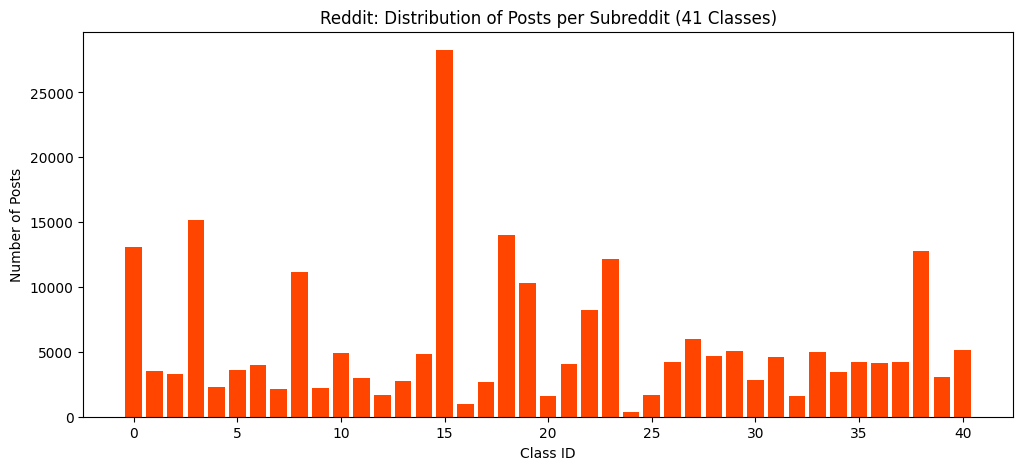

In [13]:
labels, counts = np.unique(data.y.numpy(), return_counts=True)
plt.figure(figsize=(12, 5))
plt.bar(labels, counts, color='orangered')
plt.title('Reddit: Distribution of Posts per Subreddit (41 Classes)')
plt.xlabel('Class ID')
plt.ylabel('Number of Posts')
plt.show()

# Heterogeneous

## IMDB

In [8]:
dataset = IMDB(root='../data/IMDB')
data = dataset[0] # IMDB has 1 large graph

Extracting ../data/IMDB/raw/IMDB_processed.zip
Processing...
Done!


In [20]:
print("--- Node Statistics ---")
for node_type in data.node_types:
    print(f"Node Type: {node_type} | Count: {data[node_type].num_nodes}")

print("\n--- Edge Statistics ---")
for edge_type in data.edge_types:
    print(f"Relation: {edge_type} | Count: {data[edge_type].num_edges}")

print("\n--- Feature Check ---")
for node_type in data.node_types:
    has_x = 'x' in data[node_type]
    print(f"Does {node_type} have features? {has_x}")
    if has_x:
        print(f"Feature shape: {data[node_type].x.shape}")

--- Node Statistics ---
Node Type: movie | Count: 4278
Node Type: director | Count: 2081
Node Type: actor | Count: 5257

--- Edge Statistics ---
Relation: ('movie', 'to', 'director') | Count: 4278
Relation: ('movie', 'to', 'actor') | Count: 12828
Relation: ('director', 'to', 'movie') | Count: 4278
Relation: ('actor', 'to', 'movie') | Count: 12828

--- Feature Check ---
Does movie have features? True
Feature shape: torch.Size([4278, 3066])
Does director have features? True
Feature shape: torch.Size([2081, 3066])
Does actor have features? True
Feature shape: torch.Size([5257, 3066])


=== IMDB Heterogeneous Graph EDA ===

--- Node Statistics ---
  Node Type  Count  Has Features  Feature Dim
0     movie   4278          True         3066
1  director   2081          True         3066
2     actor   5257          True         3066 

--- Edge Statistics ---
                  Relation  Count
0  movie -> to -> director   4278
1     movie -> to -> actor  12828
2  director -> to -> movie   4278
3     actor -> to -> movie  12828 

--- Label Distribution (Movie Genre) ---
Action: 1135 (26.5%)
Comedy: 1584 (37.0%)
Drama: 1559 (36.4%)


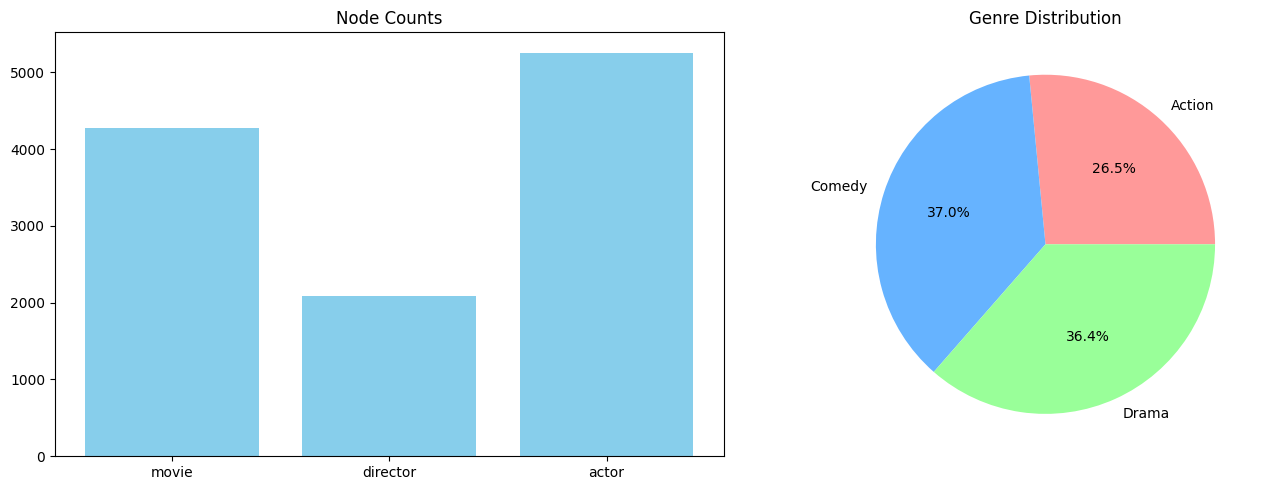


Average connections per movie: 4.00


In [6]:
def perform_hetero_eda(data):
    print("=== IMDB Heterogeneous Graph EDA ===\n")
    
    # 2. Inspect Node Types and Features
    node_data = []
    for node_type in data.node_types:
        num_nodes = data[node_type].num_nodes
        # Check if features exist
        has_x = 'x' in data[node_type]
        feat_dim = data[node_type].x.shape[1] if has_x else 0
        node_data.append({
            "Node Type": node_type,
            "Count": num_nodes,
            "Has Features": has_x,
            "Feature Dim": feat_dim
        })
    
    df_nodes = pd.DataFrame(node_data)
    print("--- Node Statistics ---")
    print(df_nodes, "\n")

    # 3. Inspect Edge Types (Triplets)
    edge_data = []
    for edge_type in data.edge_types:
        num_edges = data[edge_type].num_edges
        edge_data.append({
            "Relation": " -> ".join(edge_type),
            "Count": num_edges
        })
    
    df_edges = pd.DataFrame(edge_data)
    print("--- Edge Statistics ---")
    print(df_edges, "\n")

    # 4. Target Label Distribution (Movie Genre)
    # Target is stored in data['movie'].y
    y = data['movie'].y
    unique, counts = torch.unique(y, return_counts=True)
    
    # IMDB Mapping: 0: Action, 1: Comedy, 2: Drama
    genre_map = {0: 'Action', 1: 'Comedy', 2: 'Drama'}
    print("--- Label Distribution (Movie Genre) ---")
    for val, count in zip(unique, counts):
        print(f"{genre_map[val.item()]}: {count.item()} ({count.item()/len(y)*100:.1f}%)")

    # 5. Visualizations
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    # Plot Nodes
    ax[0].bar(df_nodes['Node Type'], df_nodes['Count'], color='skyblue')
    ax[0].set_title("Node Counts")
    
    # Plot Genres
    genre_names = [genre_map[v.item()] for v in unique]
    ax[1].pie(counts, labels=genre_names, autopct='%1.1f%%', colors=['#ff9999','#66b3ff','#99ff99'])
    ax[1].set_title("Genre Distribution")

    plt.tight_layout()
    plt.show()

# Run the EDA
perform_hetero_eda(data)

# 6. Check for Homophily (Average Degree)
total_movie_edges = data['movie', 'to', 'actor'].num_edges + data['movie', 'to', 'director'].num_edges
avg_degree = total_movie_edges / data['movie'].num_nodes
print(f"\nAverage connections per movie: {avg_degree:.2f}")

## DBLP

{'author': 4057, 'paper': 14328, 'term': 7723, 'conference': 20}
features of the node 0
[('author', 'to', 'paper'), ('paper', 'to', 'author'), ('paper', 'to', 'term'), ('paper', 'to', 'conference'), ('term', 'to', 'paper'), ('conference', 'to', 'paper')]
1


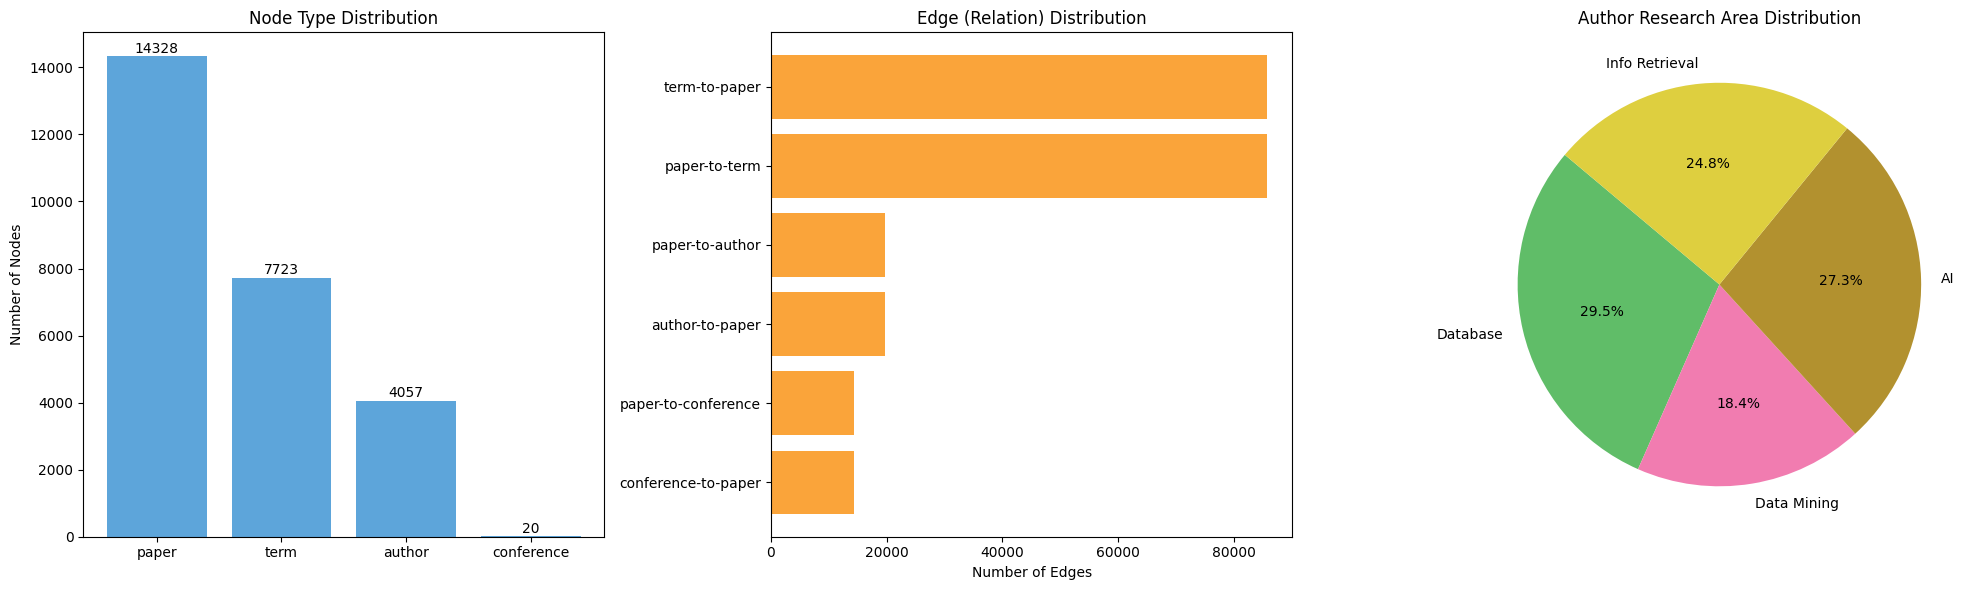

EDA Complete. Plots saved to 'dblp_statistics.png' and CSVs generated.


In [48]:
# 1. Load the Dataset
dataset = DBLP(root='../data/DBLP')
data = dataset[0]

# 2. Extract Node Statistics
node_types = data.node_types
node_counts = {nt: data[nt].num_nodes for nt in node_types}
df_nodes = pd.DataFrame(list(node_counts.items()), columns=['Node Type', 'Count']).sort_values('Count', ascending=False)
# 3. Extract Edge Statistics
# We format the edge type tuples into strings for better plot labels
edge_types = data.edge_types
edge_counts = {f"{et[0]}-{et[1]}-{et[2]}": data[et].num_edges for et in edge_types}
df_edges = pd.DataFrame(list(edge_counts.items()), columns=['Relation', 'Count']).sort_values('Count', ascending=False)
# 4. Extract Label Distribution (Target: Author)
# DBLP author classes: 0: Database, 1: Data Mining, 2: AI, 3: Information Retrieval
y = data['author'].y
unique, counts = torch.unique(y, return_counts=True)
labels = ['Database', 'Data Mining', 'AI', 'Info Retrieval']
label_counts = dict(zip(labels, counts.tolist()))
df_labels = pd.DataFrame(list(label_counts.items()), columns=['Area', 'Count'])

# --- PLOTTING ---

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Node Distribution
axes[0].bar(df_nodes['Node Type'], df_nodes['Count'], color='#5DA5DA')
axes[0].set_title('Node Type Distribution')
axes[0].set_ylabel('Number of Nodes')
for i, v in enumerate(df_nodes['Count']):
    axes[0].text(i, v + 100, str(v), ha='center')

# Plot 2: Edge Distribution
# We use a horizontal bar for edges as the names are long
axes[1].barh(df_edges['Relation'], df_edges['Count'], color='#FAA43A')
axes[1].set_title('Edge (Relation) Distribution')
axes[1].set_xlabel('Number of Edges')
axes[1].invert_yaxis() # Highest count on top

# Plot 3: Label Distribution (Author Research Areas)
axes[2].pie(df_labels['Count'], labels=df_labels['Area'], autopct='%1.1f%%', 
        startangle=140, colors=['#60BD68', '#F17CB0', '#B2912F', '#DECF3F'])
axes[2].set_title('Author Research Area Distribution')

plt.tight_layout()
plt.savefig('dblp_statistics.png')
plt.show()

# Save summary to CSV for your records
df_nodes.to_csv('dblp_node_stats.csv', index=False)
df_edges.to_csv('dblp_edge_stats.csv', index=False)
df_labels.to_csv('dblp_label_stats.csv', index=False)

print("EDA Complete. Plots saved to 'dblp_statistics.png' and CSVs generated.")

## Aminer

0


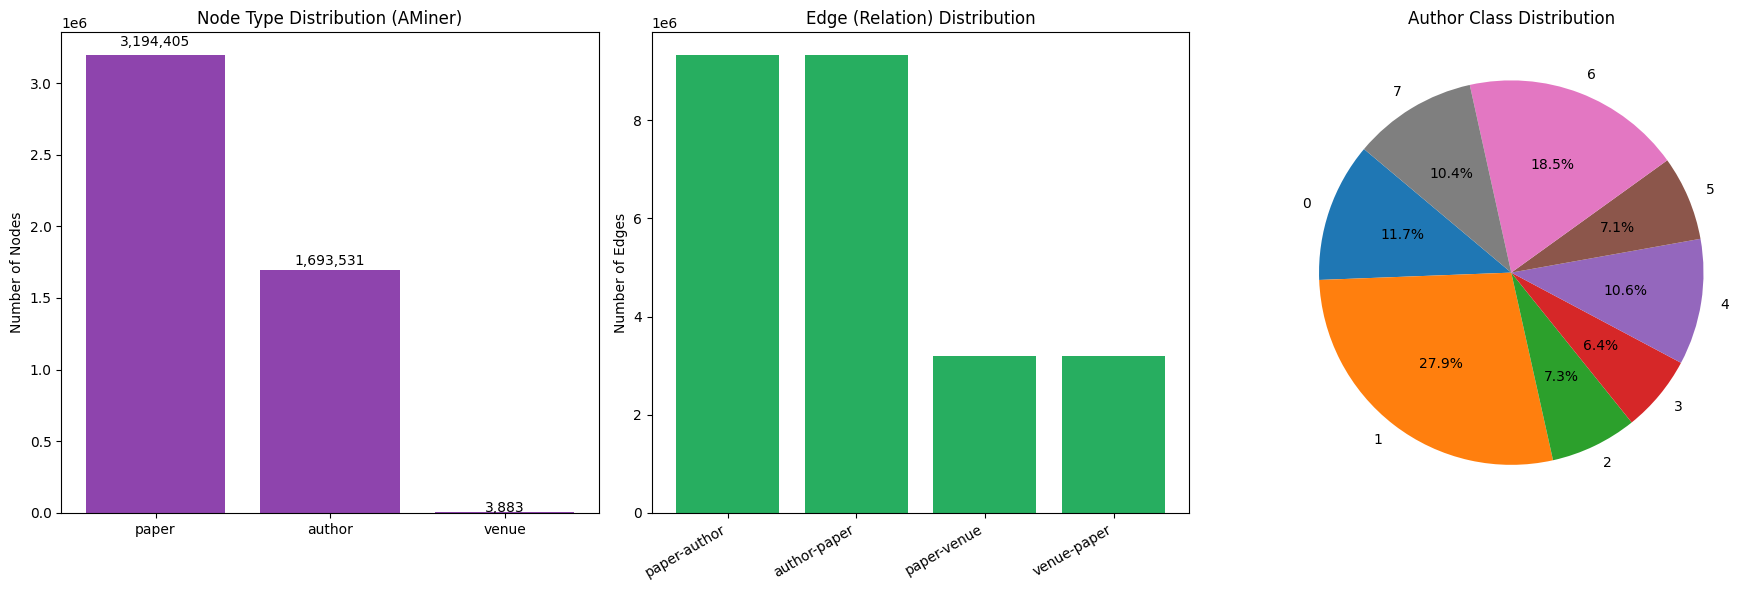

Nodes found: {'author': 1693531, 'venue': 3883, 'paper': 3194405}
Edges found: {'paper-author': 9323605, 'author-paper': 9323605, 'paper-venue': 3194405, 'venue-paper': 3194405}


In [51]:
dataset = AMiner(root='../data/AMiner')
data = dataset[0]
print(data['paper'].num_node_features)
# 2. Extract Node Statistics
node_stats = {nt: data[nt].num_nodes for nt in data.node_types}
df_nodes = pd.DataFrame(list(node_stats.items()), columns=['Node Type', 'Count']).sort_values('Count', ascending=False)

# 3. Extract Edge Statistics
# Triplet format: (src, rel, dst)
edge_stats = {f"{et[0]}-{et[2]}": data[et].num_edges for et in data.edge_types}
df_edges = pd.DataFrame(list(edge_stats.items()), columns=['Relation', 'Count']).sort_values('Count', ascending=False)

# 4. Target Label Distribution (Author)
# Note: AMiner is often used for clustering or link prediction, 
# but if using the labeled version:
if 'y' in data['author']:
    y = data['author'].y
    unique, counts = torch.unique(y, return_counts=True)
    df_labels = pd.DataFrame({'Class': unique.tolist(), 'Count': counts.tolist()})
else:
    df_labels = None

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2 if df_labels is None else 3, figsize=(18, 6))

# Plot 1: Node Distribution
axes[0].bar(df_nodes['Node Type'], df_nodes['Count'], color='#8E44AD')
axes[0].set_title('Node Type Distribution (AMiner)')
axes[0].set_ylabel('Number of Nodes')
for i, v in enumerate(df_nodes['Count']):
    axes[0].text(i, v + (v * 0.02), f"{v:,}", ha='center')

# Plot 2: Edge Distribution
axes[1].bar(df_edges['Relation'], df_edges['Count'], color='#27AE60')
axes[1].set_title('Edge (Relation) Distribution')
axes[1].set_ylabel('Number of Edges')
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")

# Plot 3: Label Distribution (if available)
if df_labels is not None:
    axes[2].pie(df_labels['Count'], labels=df_labels['Class'], autopct='%1.1f%%', startangle=140)
    axes[2].set_title('Author Class Distribution')

plt.tight_layout()
plt.savefig('aminer_stats.png')
plt.show()

print("Nodes found:", node_stats)
print("Edges found:", edge_stats)

# Knowledge Graphs

In [52]:
# 2. Download and load the individual splits (train, validation, test)
train_dataset = FB15k_237(root='../data/FB15k_237', split='train')
val_dataset   = FB15k_237(root='../data/FB15k_237', split='val')
test_dataset  = FB15k_237(root='../data/FB15k_237', split='test')

# 3. Extract the underlying Data objects
train_data = train_dataset[0]
val_data   = val_dataset[0]
test_data  = test_dataset[0]

# 4. Print out dataset statistics to confirm successful loading
print(f"--- FB15k-237 Dataset Profile ---")
print(f"Total Number of Unique Entities (Nodes): {train_data.num_nodes}")
# print(f"Number of Unique Relations (Edge Types): {train_dataset.num_edge_types}")
print("\n--- Split Edge Counts ---")
print(f"Training Triples (Edges):   {train_data.num_edges}")
print(f"Validation Triples (Edges): {val_data.num_edges}")
print(f"Testing Triples (Edges):    {test_data.num_edges}")

--- FB15k-237 Dataset Profile ---
Total Number of Unique Entities (Nodes): 14541

--- Split Edge Counts ---
Training Triples (Edges):   272115
Validation Triples (Edges): 17535
Testing Triples (Edges):    20466


In [53]:
# 3. Print out the aggregated Dataset Profile
print("==================================================")
print("       FB15K-237 DATASET PROFILE DESCRIPTION      ")
print("==================================================")
print(f"Dataset Core Class   : {train_dataset.__class__.__name__}")
print(f"Number of Entities   : {train_data.num_nodes} (Shared transductively across splits)")
print(f"Number of Relations  : {train_data.num_edge_types} unique edge relationship categories")
print(f"Node Features Dimension : {train_dataset.num_features} (No default static features)")

print("\n--- Structural Edge (Triple) Split Profile ---")
print(f"Training Triples     : {train_data.num_edges}")
print(f"Validation Triples   : {val_data.num_edges}")
print(f"Testing Triples      : {test_data.num_edges}")
print(f"Total Fact Triples   : {train_data.num_edges + val_data.num_edges + test_data.num_edges}")

print("\n--- Tensor Schema (Train Object) ---")
print(f"Edge Index Tensor Shape : {train_data.edge_index.shape} -> [2, num_edges]")
print(f"Edge Type Tensor Shape  : {train_data.edge_type.shape}  -> [num_edges]")
print("==================================================")

       FB15K-237 DATASET PROFILE DESCRIPTION      
Dataset Core Class   : FB15k_237
Number of Entities   : 14541 (Shared transductively across splits)
Number of Relations  : 237 unique edge relationship categories
Node Features Dimension : 0 (No default static features)

--- Structural Edge (Triple) Split Profile ---
Training Triples     : 272115
Validation Triples   : 17535
Testing Triples      : 20466
Total Fact Triples   : 310116

--- Tensor Schema (Train Object) ---
Edge Index Tensor Shape : torch.Size([2, 272115]) -> [2, num_edges]
Edge Type Tensor Shape  : torch.Size([272115])  -> [num_edges]


In [75]:
# 2. Initialize the dataset (Only pass the root directory!)
dataset = WordNet18RR(root='../data/WN18RR')
data = dataset[0]  # This contains the entire graph structure
print(dataset)
# 3. Access the edge splits using the internal masks
# PyG stores everything inside a single data object using boolean masks
train_mask = data.train_mask
val_mask   = data.val_mask
test_mask  = data.test_mask

# 4. Profile the statistics correctly
print(f"--- WN18RR Dataset Profile ---")
print(f"Total Number of Unique Entities (Nodes): {data.num_nodes}")
# print(f"Number of Unique Relations (Edge Types): {dataset.num_edge_types}")
print("\n--- Split Edge Counts (Triples) ---")
print(f"Training Triples (Edges):   {int(train_mask.sum())}")
print(f"Validation Triples (Edges): {int(val_mask.sum())}")
print(f"Testing Triples (Edges):    {int(test_mask.sum())}")

WordNet18RR()
--- WN18RR Dataset Profile ---
Total Number of Unique Entities (Nodes): 40943

--- Split Edge Counts (Triples) ---
Training Triples (Edges):   86835
Validation Triples (Edges): 3034
Testing Triples (Edges):    3134


In [72]:
edge_idx = 0

# 3. Extract the components of the triple
head_node_id = data.edge_index[0, edge_idx].item()  # The Subject node ID
tail_node_id = data.edge_index[1, edge_idx].item()  # The Object node ID
relation_id  = data.edge_type[edge_idx].item()       # The Relation type ID

print(head_node_id,relation_id,tail_node_id)

0 3 10211


# Heterophilous Networks

In [76]:
# 2. Download and load the Cornell subset specifically
dataset = WebKB(root='../data', name='Cornell')
data = dataset[0]  # Get the graph data object

# 3. Print dataset profile information
print(f"--- Cornell (WebKB) Dataset Profile ---")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of Nodes (Webpages): {data.num_nodes}")
print(f"Number of Edges (Hyperlinks): {data.num_edges}")
print(f"Number of Node Features: {dataset.num_features}")
print(f"Number of Target Classes: {dataset.num_classes}")

# 4. Check the mask dimensions (WebKB datasets come with 10 different train/val/test splits)
print("\n--- Split Masks Shape ---")
print(f"Train Mask Shape: {data.train_mask.shape} (Contains 10 different random splits)")

--- Cornell (WebKB) Dataset Profile ---
Number of Graphs: 1
Number of Nodes (Webpages): 183
Number of Edges (Hyperlinks): 298
Number of Node Features: 1703
Number of Target Classes: 5

--- Split Masks Shape ---
Train Mask Shape: torch.Size([183, 10]) (Contains 10 different random splits)


In [78]:
# 2. Download and load the Cornell subset specifically
dataset = WebKB(root='../data', name='Texas')
data = dataset[0]  # Get the graph data object

# 3. Print dataset profile information
print(f"--- Cornell (WebKB) Dataset Profile ---")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of Nodes (Webpages): {data.num_nodes}")
print(f"Number of Edges (Hyperlinks): {data.num_edges}")
print(f"Number of Node Features: {dataset.num_features}")
print(f"Number of Target Classes: {dataset.num_classes}")

# 4. Check the mask dimensions (WebKB datasets come with 10 different train/val/test splits)
print("\n--- Split Masks Shape ---")
print(f"Train Mask Shape: {data.train_mask.shape} (Contains 10 different random splits)")

--- Cornell (WebKB) Dataset Profile ---
Number of Graphs: 1
Number of Nodes (Webpages): 183
Number of Edges (Hyperlinks): 325
Number of Node Features: 1703
Number of Target Classes: 5

--- Split Masks Shape ---
Train Mask Shape: torch.Size([183, 10]) (Contains 10 different random splits)


In [80]:
# 2. Download and load the Cornell subset specifically
dataset = WebKB(root='../data', name='Wisconsin')
data = dataset[0]  # Get the graph data object

# 3. Print dataset profile information
print(f"--- Cornell (WebKB) Dataset Profile ---")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of Nodes (Webpages): {data.num_nodes}")
print(f"Number of Edges (Hyperlinks): {data.num_edges}")
print(f"Number of Node Features: {dataset.num_features}")
print(f"Number of Target Classes: {dataset.num_classes}")

# 4. Check the mask dimensions (WebKB datasets come with 10 different train/val/test splits)
print("\n--- Split Masks Shape ---")
print(f"Train Mask Shape: {data.train_mask.shape} (Contains 10 different random splits)")

--- Cornell (WebKB) Dataset Profile ---
Number of Graphs: 1
Number of Nodes (Webpages): 251
Number of Edges (Hyperlinks): 515
Number of Node Features: 1703
Number of Target Classes: 5

--- Split Masks Shape ---
Train Mask Shape: torch.Size([251, 10]) (Contains 10 different random splits)


In [81]:
dataset = WikipediaNetwork(root='../data', name='chameleon', geom_gcn_preprocess=True)
data = dataset[0]

# 3. Print the data architecture
print(f"--- Chameleon Dataset Profile ---")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of Nodes (Wiki Pages): {data.num_nodes}")
print(f"Number of Edges (Hyperlinks): {data.num_edges}")
print(f"Number of Node Features: {dataset.num_features}")
print(f"Number of Target Classes: {dataset.num_classes}")

# 4. Show the multi-split mask dimensions
print("\n--- Split Profile ---")
print(f"Train Mask Matrix Shape: {data.train_mask.shape}")

--- Chameleon Dataset Profile ---
Number of Graphs: 1
Number of Nodes (Wiki Pages): 2277
Number of Edges (Hyperlinks): 36101
Number of Node Features: 2325
Number of Target Classes: 5

--- Split Profile ---
Train Mask Matrix Shape: torch.Size([2277, 10])


In [82]:
dataset = Actor(root='../data/Film_Actor')
data = dataset[0]

# 3. Print the data architecture properties
print(f"--- Film (Actor) Dataset Profile ---")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of Nodes (Actors): {data.num_nodes}")
print(f"Number of Edges (Co-occurrences): {data.num_edges}")
print(f"Number of Node Features: {dataset.num_features}")
print(f"Number of Target Classes: {dataset.num_classes}")

# 4. Check the mask matrix shape
print("\n--- Split Profile ---")
print(f"Train Mask Matrix Shape: {data.train_mask.shape}")

--- Film (Actor) Dataset Profile ---
Number of Graphs: 1
Number of Nodes (Actors): 7600
Number of Edges (Co-occurrences): 30019
Number of Node Features: 932
Number of Target Classes: 5

--- Split Profile ---
Train Mask Matrix Shape: torch.Size([7600, 10])


In [83]:
# 2. Download and parse the Squirrel subset
# geom_gcn_preprocess=True guarantees the standard 5-class target matrix
dataset = WikipediaNetwork(root='../data/', name='squirrel', geom_gcn_preprocess=True)
data = dataset[0]

# 3. Print out structural characteristics 
print(f"--- Squirrel Dataset Profile ---")
print(f"Number of Graphs: {len(dataset)}")
print(f"Number of Nodes (Wiki Pages): {data.num_nodes}")
print(f"Number of Edges (Hyperlinks): {data.num_edges}")
print(f"Number of Node Features: {dataset.num_features}")
print(f"Number of Target Classes: {dataset.num_classes}")

# 4. Check multi-split mask dimension
print("\n--- Split Profile ---")
print(f"Train Mask Matrix Shape: {data.train_mask.shape}")

--- Squirrel Dataset Profile ---
Number of Graphs: 1
Number of Nodes (Wiki Pages): 5201
Number of Edges (Hyperlinks): 217073
Number of Node Features: 2089
Number of Target Classes: 5

--- Split Profile ---
Train Mask Matrix Shape: torch.Size([5201, 10])
